## Cell 1 — Setup & Connection

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pyodbc
from dotenv import load_dotenv
import os
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score
import warnings
warnings.filterwarnings('ignore')

load_dotenv('../.env')

def get_connection():
    cs = (
        f"DRIVER={{ODBC Driver 17 for SQL Server}};"
        f"SERVER={os.getenv('DB_SERVER')},1433;"
        f"DATABASE={os.getenv('DB_NAME')};"
        f"UID={os.getenv('DB_USERNAME')};"
        f"PWD={os.getenv('DB_PASSWORD')};"
        f"Encrypt=yes;TrustServerCertificate=no;Connection Timeout=30;"
    )
    return pyodbc.connect(cs)

conn = get_connection()
print("✅ Connected to Azure SQL!")


✅ Connected to Azure SQL!


## Cell 2 — Load Live Match Data & Build Team Stats

In [2]:
matches_full_df = pd.read_sql("""
    SELECT m.match_id, m.match_date, m.group_name,
           t1.team_name as home_team, t1.fifa_code as home_code,
           m.home_score, m.away_score,
           t2.team_name as away_team, t2.fifa_code as away_code
    FROM matches m
    JOIN teams t1 ON m.home_team_id = t1.team_id
    JOIN teams t2 ON m.away_team_id = t2.team_id
    WHERE m.home_score IS NOT NULL
""", conn)

teams_df = pd.read_sql("SELECT * FROM teams", conn)
print(f"✅ Loaded {len(matches_full_df)} completed matches")
print(f"✅ Loaded {len(teams_df)} teams")

def build_team_stats(matches_df):
    stats = {}
    for _, match in matches_df.iterrows():
        home, away = match['home_team'], match['away_team']
        hg, ag = int(match['home_score']), int(match['away_score'])
        group = match['group_name'].replace('GROUP_', '')
        for team, gf, ga, is_home in [(home, hg, ag, 1), (away, ag, hg, 0)]:
            if team not in stats:
                stats[team] = {
                    'team': team, 'group': group, 'played': 0,
                    'won': 0, 'drawn': 0, 'lost': 0,
                    'goals_for': 0, 'goals_against': 0, 'points': 0,
                    'home_games': 0, 'clean_sheets': 0,
                    'failed_to_score': 0, 'biggest_win': 0, 'momentum': []
                }
            s = stats[team]
            s['played'] += 1; s['goals_for'] += gf; s['goals_against'] += ga
            s['home_games'] += is_home
            if ga == 0: s['clean_sheets'] += 1
            if gf == 0: s['failed_to_score'] += 1
            margin = gf - ga
            if margin > s['biggest_win']: s['biggest_win'] = margin
            if gf > ga:   s['won'] += 1; s['points'] += 3; s['momentum'].append(3)
            elif gf == ga: s['drawn'] += 1; s['points'] += 1; s['momentum'].append(1)
            else:          s['lost'] += 1; s['momentum'].append(0)

    for team, s in stats.items():
        p = s['played']
        s['goal_difference']        = s['goals_for'] - s['goals_against']
        s['goals_per_game']         = round(s['goals_for'] / p, 2) if p else 0
        s['goals_conceded_per_game']= round(s['goals_against'] / p, 2) if p else 0
        s['win_rate']               = round(s['won'] / p, 2) if p else 0
        s['points_per_game']        = round(s['points'] / p, 2) if p else 0
        mom = s['momentum']
        if mom:
            w = np.array([0.5, 0.3, 0.2][:len(mom)]); w /= w.sum()
            recent = mom[-3:]; rw = w[-len(recent):]; rw /= rw.sum()
            s['momentum_score'] = round(float(np.dot(recent, rw)), 2)
        else:
            s['momentum_score'] = 0

    return pd.DataFrame(stats.values())

team_stats_df = build_team_stats(matches_full_df)
print(f"\n✅ Built features for {len(team_stats_df)} teams")
team_stats_df.sort_values('points', ascending=False).head(10)


✅ Loaded 72 completed matches
✅ Loaded 48 teams

✅ Built features for 48 teams


,team,group,played,won,drawn,lost,goals_for,goals_against,points,home_games,clean_sheets,failed_to_score,biggest_win,momentum,goal_difference,goals_per_game,goals_conceded_per_game,win_rate,points_per_game,momentum_score
0,Mexico,A,3,3,0,0,6,0,9,2,3,0,3,"[3, 3, 3]",6,2.00,0.00,1.00,3.00,3.0
36,Argentina,J,3,3,0,0,8,1,9,2,2,0,3,"[3, 3, 3]",7,2.67,0.33,1.00,3.00,3.0
32,France,I,3,3,0,0,10,2,9,2,1,0,3,"[3, 3, 3]",8,3.33,0.67,1.00,3.00,3.0
11,Morocco,C,3,2,1,0,6,3,7,1,1,0,2,"[1, 3, 3]",3,2.00,1.00,0.67,2.33,2.0
24,Spain,H,3,2,1,0,5,0,7,2,3,1,4,"[1, 3, 3]",5,1.67,0.00,0.67,2.33,2.0
18,Netherlands,F,3,2,1,0,10,4,7,2,0,0,4,"[1, 3, 3]",6,3.33,1.33,0.67,2.33,2.0
10,Brazil,C,3,2,1,0,7,1,7,2,2,0,3,"[1, 3, 3]",6,2.33,0.33,0.67,2.33,2.0
9,Switzerland,B,3,2,1,0,7,3,7,2,0,0,3,"[1, 3, 3]",4,2.33,1.00,0.67,2.33,2.0
47,Colombia,K,3,2,1,0,4,1,7,2,2,1,2,"[3, 3, 1]",3,1.33,0.33,0.67,2.33,2.6
42,England,L,3,2,1,0,6,2,7,2,2,1,2,"[3, 1, 3]",4,2.00,0.67,0.67,2.33,2.4


## Cell 3 — FIFA Rankings

In [3]:
fifa_rankings = {
    'France': 2, 'Spain': 3, 'England': 4, 'Brazil': 5,
    'Portugal': 6, 'Netherlands': 7, 'Argentina': 8,
    'Belgium': 9, 'Germany': 10, 'Morocco': 13,
    'United States': 14, 'Mexico': 15, 'Switzerland': 16,
    'Croatia': 17, 'Uruguay': 18, 'Colombia': 19,
    'Japan': 20, 'Ecuador': 21, 'Senegal': 22,
    'Sweden': 23, 'South Korea': 24, 'Turkey': 25,
    'Australia': 26, 'Canada': 27, 'Saudi Arabia': 28,
    'Egypt': 31, 'Austria': 32, 'South Africa': 64,
    'Ghana': 54, 'Tunisia': 30, 'Ivory Coast': 48,
    'Norway': 34, 'Scotland': 38, 'Czech Republic': 40,
    'Czechia': 40, 'Iran': 20, 'Qatar': 35,
    'Bosnia-Herzegovina': 55, 'Paraguay': 58,
    'Algeria': 42, 'New Zealand': 100, 'Jordan': 87,
    'Iraq': 63, 'Uzbekistan': 50, 'Congo DR': 56,
    'Cape Verde Islands': 80, 'Haiti': 83,
    'Curaçao': 85, 'Panama': 70
}

team_stats_df['fifa_ranking'] = team_stats_df['team'].map(fifa_rankings).fillna(90)
team_stats_df['ranking_tier'] = pd.cut(
    team_stats_df['fifa_ranking'],
    bins=[0, 10, 25, 50, 100, 200],
    labels=['Elite', 'Strong', 'Mid', 'Lower', 'Minnow']
)
print("✅ FIFA Rankings added!")
print(team_stats_df.groupby('ranking_tier')['team'].count())


✅ FIFA Rankings added!
ranking_tier
Elite      9
Strong    14
Mid       13
Lower     12
Minnow     0
Name: team, dtype: int64


## Cell 4 — Historical Training Data (2018 + 2022)

In [4]:
import requests

API_KEY   = os.getenv('FOOTBALL_API_KEY')
BASE_URL  = "https://api.football-data.org/v4"
HEADERS   = {"X-Auth-Token": API_KEY}

verified_2018 = [
    ('Uruguay',9,5,5,14,1),('Russia',6,5,8,70,1),
    ('France',7,3,3,7,1),('Denmark',5,2,3,12,1),
    ('Croatia',7,5,7,20,1),('Argentina',4,0,3,5,1),
    ('Brazil',7,4,5,2,1),('Switzerland',5,1,5,6,1),
    ('Belgium',9,7,8,3,1),('Japan',4,0,4,61,1),
    ('Sweden',6,4,6,24,1),('Mexico',6,2,3,15,1),
    ('Colombia',6,3,5,16,1),('England',6,5,8,13,1),
    ('Senegal',4,0,4,27,1),('Nigeria',3,-1,3,48,1),
    ('Poland',3,-2,2,8,0),('Germany',3,-2,2,1,0),
    ('Portugal',5,1,4,4,0),('Spain',5,1,4,10,0),
    ('Iran',4,0,2,37,0),('Peru',0,-4,2,11,0),
    ('Morocco',1,-1,2,48,0),('Iceland',1,-3,2,22,0),
    ('Australia',1,-3,2,41,0),('Saudi Arabia',1,-4,2,67,0),
    ('Egypt',0,-4,2,45,0),('Tunisia',1,-2,5,21,0),
    ('Panama',0,-7,2,55,0),('South Korea',3,-3,3,57,0),
    ('Costa Rica',0,-5,2,23,0),('Serbia',3,-1,2,34,0),
]

all_historical = []
for row in verified_2018:
    all_historical.append({
        'year': 2018, 'team': row[0], 'points': row[1],
        'goal_difference': row[2], 'goals_for': row[3],
        'goals_per_game': round(row[3]/3, 2),
        'fifa_ranking': row[4], 'advanced': row[5]
    })

advanced_2022 = [
    'Netherlands','Senegal','England','United States',
    'Argentina','Poland','France','Australia',
    'Japan','Spain','Morocco','Croatia',
    'Brazil','Switzerland','Portugal','South Korea'
]

try:
    r = requests.get(f"{BASE_URL}/competitions/WC/matches", headers=HEADERS)
    if r.status_code == 200:
        gm = [m for m in r.json().get('matches',[])
              if m.get('stage')=='GROUP_STAGE'
              and m.get('score',{}).get('fullTime',{}).get('home') is not None]
        s22 = {}
        for m in gm:
            home,away = m['homeTeam']['name'],m['awayTeam']['name']
            hg,ag = m['score']['fullTime']['home'],m['score']['fullTime']['away']
            for team,gf,ga in [(home,hg,ag),(away,ag,hg)]:
                if team not in s22: s22[team]={'played':0,'goals_for':0,'goals_against':0,'points':0}
                s=s22[team]; s['played']+=1; s['goals_for']+=gf; s['goals_against']+=ga
                if gf>ga: s['points']+=3
                elif gf==ga: s['points']+=1
        for team,s in s22.items():
            p=s['played']
            if p>0:
                all_historical.append({
                    'year':2022,'team':team,'points':s['points'],
                    'goal_difference':s['goals_for']-s['goals_against'],
                    'goals_for':s['goals_for'],
                    'goals_per_game':round(s['goals_for']/p,2),
                    'fifa_ranking':fifa_rankings.get(team,80),
                    'advanced':1 if team in advanced_2022 else 0
                })
        print(f"✅ 2022 data fetched: {len(s22)} teams")
    else:
        print("⚠️ 2022 API unavailable — using 2018 only")
except Exception as e:
    print(f"⚠️ Could not fetch 2022 data: {e}")

hist_df = pd.DataFrame(all_historical).drop_duplicates(subset=['year','team'])
print(f"✅ Total historical records: {len(hist_df)}")
for yr in sorted(hist_df['year'].unique()):
    print(f"   {yr}: {len(hist_df[hist_df['year']==yr])} teams")


✅ 2022 data fetched: 48 teams
✅ Total historical records: 80
   2018: 32 teams
   2022: 48 teams


## Cell 5 — Train Random Forest Model

In [5]:
features = ['points','goal_difference','goals_for','goals_per_game','fifa_ranking']

X = hist_df[features]; y = hist_df['advanced']
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
lr_model = LogisticRegression(random_state=42)
rf_model.fit(X_scaled, y)
lr_model.fit(X_scaled, y)

rf_cv = cross_val_score(rf_model, X_scaled, y, cv=5, scoring='accuracy')
print(f"Random Forest CV accuracy: {rf_cv.mean():.2%} (+/- {rf_cv.std():.2%})")

fi = pd.DataFrame({'feature':features,'importance':rf_model.feature_importances_}).sort_values('importance',ascending=False)
print("\n📊 Feature Importance:")
for _,row in fi.iterrows():
    print(f"  {row['feature']:<25} {'█'*int(row['importance']*50)} {row['importance']:.2%}")


Random Forest CV accuracy: 72.50% (+/- 9.35%)

📊 Feature Importance:
  fifa_ranking              ███████████████ 31.35%
  goal_difference           █████████████ 26.69%
  points                    █████████ 19.96%
  goals_per_game            █████ 11.65%
  goals_for                 █████ 10.33%


## Cell 6 — Group Advancement Predictions

In [6]:
current_features = team_stats_df[[
    'team','group','points','goal_difference','played',
    'goals_for','goals_per_game','fifa_ranking','momentum_score','clean_sheets'
]].copy()

X_cur = current_features[features]
X_cur_scaled = scaler.transform(X_cur)
raw_probs = rf_model.predict_proba(X_cur_scaled)[:,1]

def apply_ranking_floor(prob, ranking, games_played):
    form_w  = min(games_played / 3, 1.0)
    rank_w  = 1 - form_w
    if   ranking <= 10: floor = 0.55 * rank_w
    elif ranking <= 20: floor = 0.40 * rank_w
    elif ranking <= 35: floor = 0.25 * rank_w
    else:               floor = 0.10 * rank_w
    return round(float((prob * form_w) + (max(prob, floor) * rank_w)), 3)

def points_based_boost(points, gd):
    if   points >= 3 and gd >= 2: return  0.35
    elif points >= 3:              return  0.20
    elif points == 0 and gd <= -2:return -0.15
    return 0.0

adj, raw_pct = [], []
for i, (_, row) in enumerate(current_features.iterrows()):
    boost = points_based_boost(row['points'], row['goal_difference'])
    rwb   = min(max(raw_probs[i] + boost, 0.02), 0.98)
    adj.append(apply_ranking_floor(rwb, row['fifa_ranking'], row['played']))
    raw_pct.append(round(raw_probs[i] * 100, 1))

current_features['raw_prob_pct']       = raw_pct
current_features['advancement_prob']   = adj
current_features['advancement_prob_pct'] = (current_features['advancement_prob']*100).round(1)

predictions = current_features.sort_values('advancement_prob', ascending=False)

print("="*80)
print("🏆 FIFA WORLD CUP 2026 — GROUP ADVANCEMENT PREDICTIONS")
print("="*80)
print(f"\n{'Team':<22}{'Grp':>4}{'P':>3}{'Pts':>4}{'GD':>4}{'Rank':>5}{'Raw%':>6}{'Adj%':>6}")
print("-"*80)
for _, row in predictions.iterrows():
    adj_v = row['advancement_prob_pct']
    emoji = "🟢" if adj_v >= 60 else "🟡" if adj_v >= 35 else "🔴"
    print(f"{emoji} {row['team']:<20}{row['group']:>4}{int(row['played']):>3}"
          f"{int(row['points']):>4}{int(row['goal_difference']):>4}"
          f"{int(row['fifa_ranking']):>5}{row['raw_prob_pct']:>5}%{adj_v:>5}%")


🏆 FIFA WORLD CUP 2026 — GROUP ADVANCEMENT PREDICTIONS

Team                   Grp  P Pts  GD Rank  Raw%  Adj%
--------------------------------------------------------------------------------
🟢 United States          D  3   6   4   14100.0% 98.0%
🟢 Morocco                C  3   7   3   13 94.0% 98.0%
🟢 Brazil                 C  3   7   6    5 96.0% 98.0%
🟢 Switzerland            B  3   7   4   16 97.0% 98.0%
🟢 Australia              D  3   4   0   26 80.0% 98.0%
🟢 Spain                  H  3   7   5    3 99.0% 98.0%
🟢 Netherlands            F  3   7   6    7 82.0% 98.0%
🟢 Croatia                L  3   6   0   17 81.0% 98.0%
🟢 France                 I  3   9   8    2 89.0% 98.0%
🟢 Senegal                I  3   3   2   22 72.0% 98.0%
🟢 Argentina              J  3   9   7    8 96.0% 98.0%
🟢 Portugal               K  3   5   5    6 85.0% 98.0%
🟢 England                L  3   7   4    4 97.0% 98.0%
🟢 Japan                  F  3   5   4   20 83.0% 98.0%
🟢 South Korea            A  3   3  -1  

## Cell 7 — Group by Group Breakdown Chart

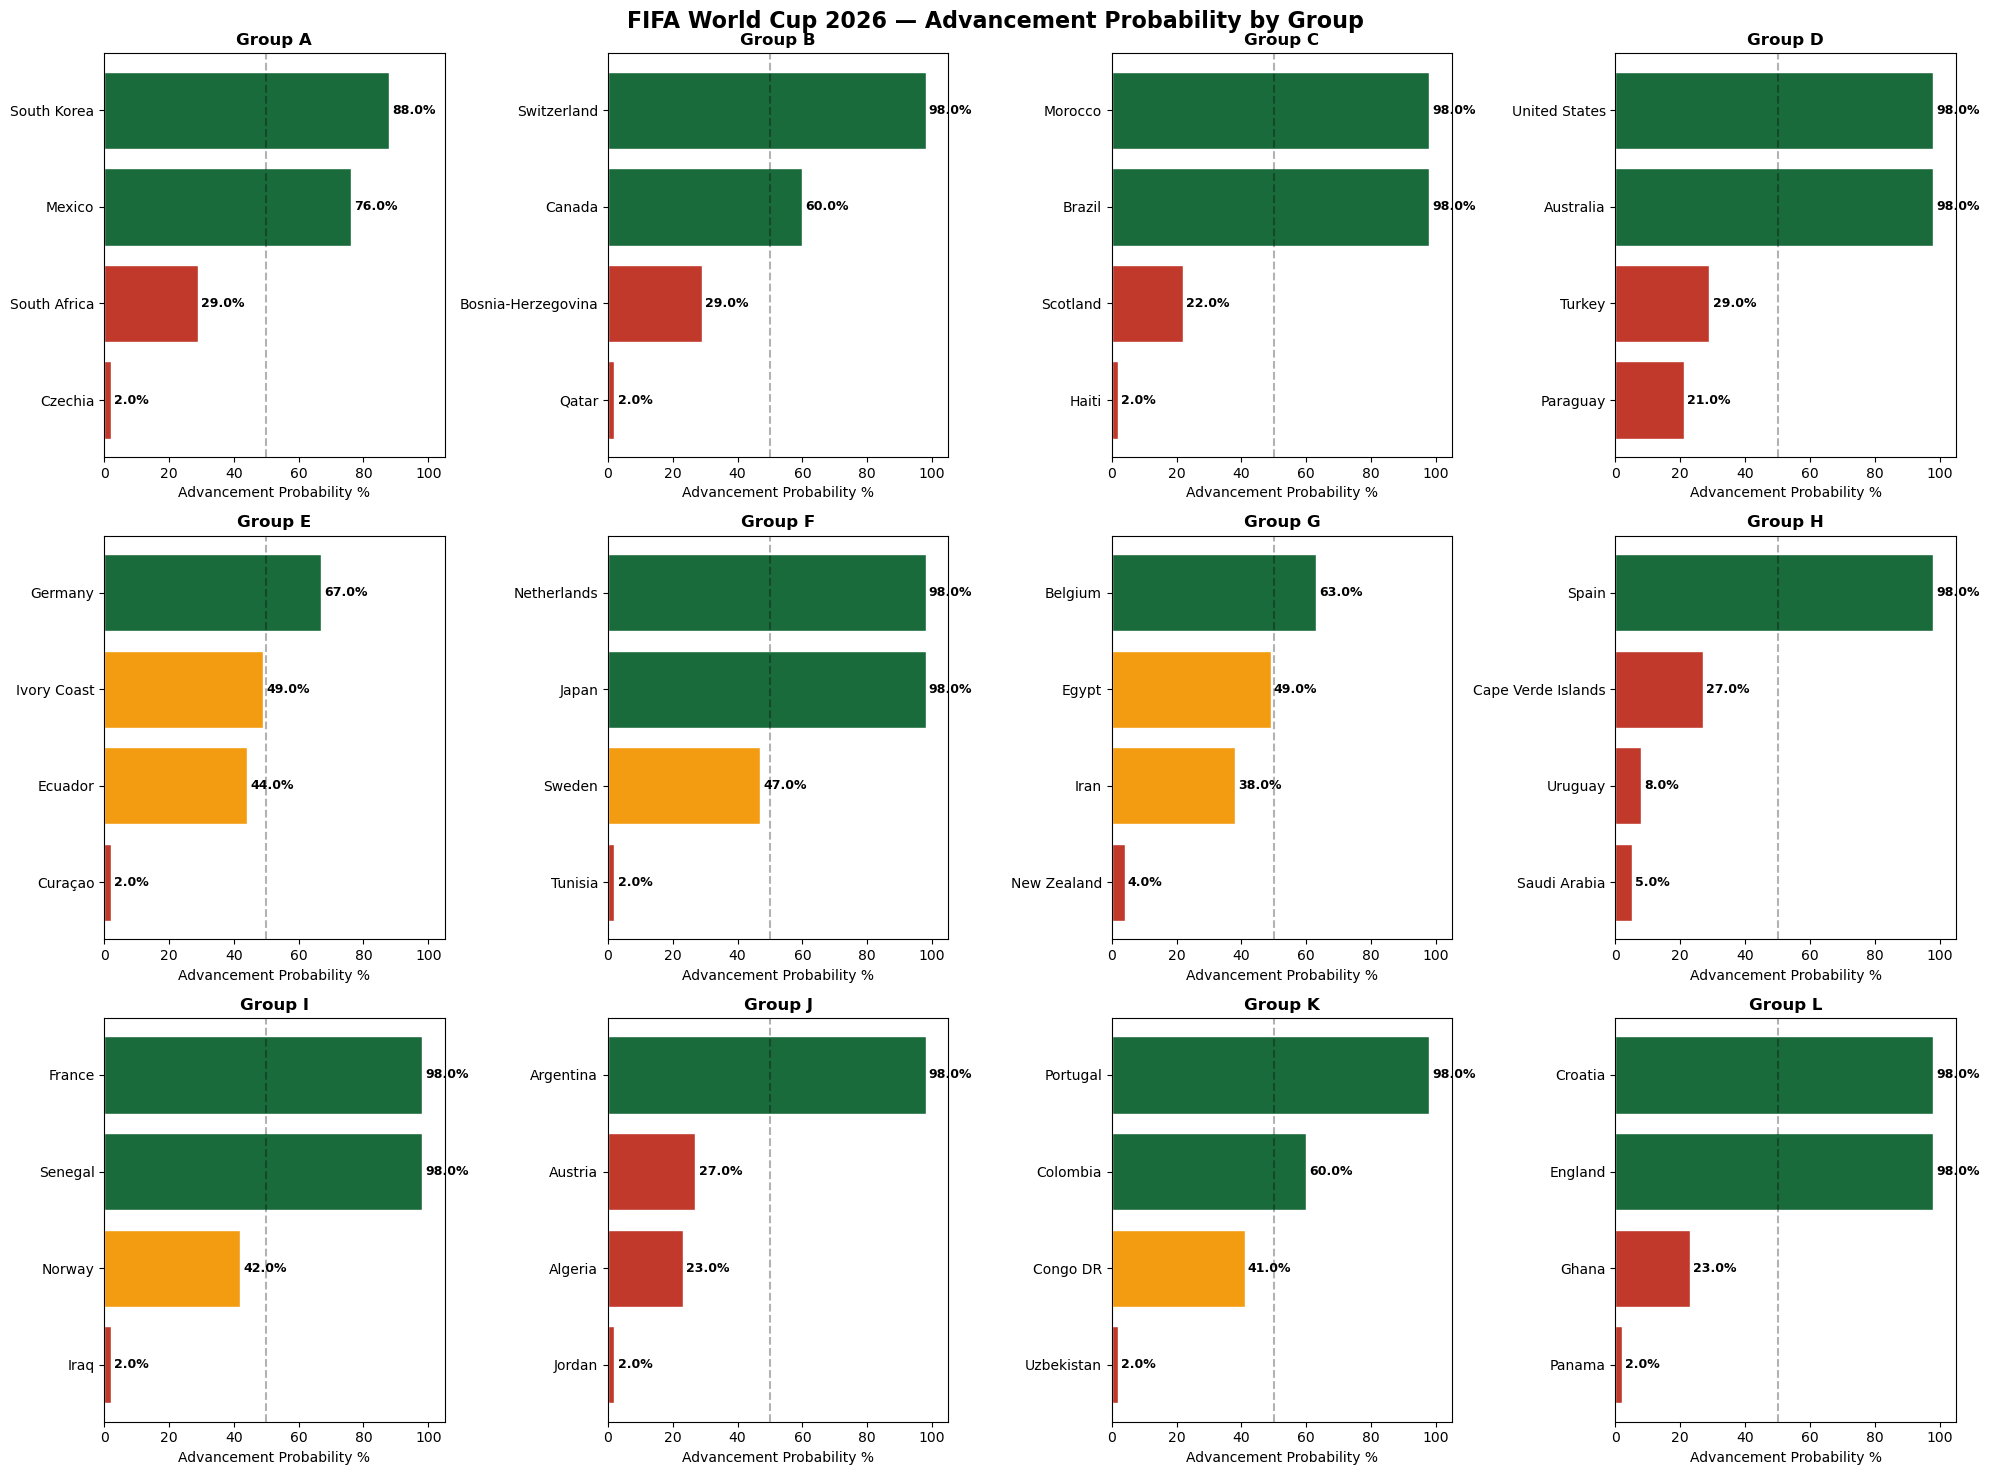

✅ Chart saved


In [7]:
groups  = sorted(predictions['group'].unique())
n_cols  = 4
n_rows  = (len(groups) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5*n_rows))
fig.suptitle('FIFA World Cup 2026 — Advancement Probability by Group', fontsize=16, fontweight='bold')
axes = axes.flatten()

for idx, group in enumerate(groups):
    ax = axes[idx]
    gd = predictions[predictions['group']==group].sort_values('advancement_prob', ascending=True)
    colors = ['#1a6b3c' if p>=60 else '#f39c12' if p>=35 else '#c0392b' for p in gd['advancement_prob_pct']]
    bars = ax.barh(gd['team'], gd['advancement_prob_pct'], color=colors, edgecolor='white')
    ax.set_title(f'Group {group}', fontweight='bold')
    ax.set_xlabel('Advancement Probability %'); ax.set_xlim(0,105)
    ax.axvline(x=50, color='black', linestyle='--', alpha=0.3)
    for bar, val in zip(bars, gd['advancement_prob_pct']):
        ax.text(val+1, bar.get_y()+bar.get_height()/2, f'{val}%', va='center', fontsize=9, fontweight='bold')

for idx in range(len(groups), len(axes)): axes[idx].axis('off')
plt.tight_layout()
plt.savefig('../data/advancement_predictions.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ Chart saved")


## Cell 8 — Monte Carlo Bracket Simulator (Real WC 2026 Bracket)

In [8]:
# ============================================================
# MONTE CARLO BRACKET SIMULATOR — Real WC 2026 Structure
# ============================================================
# Strength formula: 55% form + 15% ranking + 15% momentum + 15% defence
# - Form (advancement_prob) captures everything the RF model learned
#   from live match data: points, GD, goals, goals per game
# - Ranking weight kept at 15% — form dominates after 2+ games
# - Defensive score rewards 0-conceded teams (Argentina boost)
# - Upset compression 0.65 — any team can win on the day
# - Real FIFA bracket: 32 teams, confirmed R32 pairings from FIFA
# ============================================================

import numpy as np

N_SIMULATIONS = 10000
np.random.seed(42)

# ── Defensive score ──────────────────────────────────────────
# Pull goals_conceded_per_game from team_stats_df
gcpg = team_stats_df.set_index('team')['goals_conceded_per_game'].to_dict()
predictions['goals_conceded_per_game'] = predictions['team'].map(gcpg).fillna(1.0)
predictions['defensive_score'] = 1 / (predictions['goals_conceded_per_game'] + 0.5)
predictions['defensive_score'] = predictions['defensive_score'] / predictions['defensive_score'].max()

# ── Strength score ───────────────────────────────────────────
# 55% form | 15% ranking | 15% momentum | 15% defence
# Form already encodes ranking partially via the RF model training
# so we deliberately reduce standalone ranking weight here
predictions['mc_strength'] = (
    predictions['advancement_prob']           * 0.55 +
    (1 / predictions['fifa_ranking']) * 30    * 0.15 +
    predictions['momentum_score']             * 0.15 +
    predictions['defensive_score']            * 0.15
)

strength = dict(zip(predictions['team'], predictions['mc_strength']))

# ── Match simulator ──────────────────────────────────────────
def simulate_match(a, b):
    sa = strength.get(a, 0.01); sb = strength.get(b, 0.01)
    p  = sa / (sa + sb)
    p  = 0.5 + (p - 0.5) * 0.65   # upset compression
    return a if np.random.random() < p else b

# ── Group result selector ────────────────────────────────────
def get_group_results(pdf):
    results      = {}
    third_teams  = []
    for group in sorted(pdf['group'].unique()):
        gteams = pdf[pdf['group']==group].copy().sort_values('advancement_prob', ascending=False)
        teams  = gteams['team'].tolist()
        probs  = np.clip(gteams['advancement_prob'].values, 0.01, None)

        # 1st and 2nd — probabilistic weighted choice among top 2
        top2     = teams[:2]
        top2_p   = probs[:2] / probs[:2].sum()
        first    = np.random.choice(top2, p=top2_p)
        second   = [t for t in top2 if t != first][0]

        # 3rd — from remaining teams
        bottom   = teams[2:] if len(teams) > 2 else [teams[-1]]
        bot_p    = probs[len(top2):len(top2)+len(bottom)]
        if bot_p.sum() > 0:
            bot_p = bot_p / bot_p.sum()
            third = np.random.choice(bottom, p=bot_p)
        else:
            third = bottom[0]

        row3 = gteams[gteams['team']==third].iloc[0]
        third_teams.append({
            'team':  third, 'group': group,
            'points':int(row3['points']),
            'gd':    int(row3['goal_difference']),
            'gf':    int(row3['goals_for']),
            'str':   strength.get(third, 0.01)
        })
        results[group] = {'1': first, '2': second, '3': third}

    # Best 8 third-place teams: ranked by pts, GD, GF, strength
    third_teams.sort(key=lambda x: (x['points'], x['gd'], x['gf'], x['str']), reverse=True)
    best8 = [t['team'] for t in third_teams[:8]]
    return results, best8

# ── Real WC 2026 R32 bracket ─────────────────────────────────
# Source: FIFA official + confirmed by ESPN/SI
# Fixed winner-vs-runner-up pairings
FIXED_PAIRS = [
    ('A',1,'B',2),  # 1A vs 2B
    ('B',1,'A',2),  # 1B vs 2A
    ('C',1,'F',2),  # 1C vs 2F
    ('F',1,'C',2),  # 1F vs 2C
    ('H',1,'J',2),  # 1H vs 2J  (Spain/Uruguay bracket vs Argentina/Algeria)
    ('J',1,'H',2),  # 1J vs 2H
    ('D',2,'G',2),  # 2D vs 2G
    ('E',2,'I',2),  # 2E vs 2I
    ('K',2,'L',2),  # 2K vs 2L
]
# 6 group winners face best 3rd place teams
WINNERS_VS_3RD = ['D','E','G','I','K','L']

def build_r32(results, best8):
    r32 = []
    # Fixed pairings
    for g1,p1,g2,p2 in FIXED_PAIRS:
        t1 = results.get(g1,{}).get(str(p1),'TBD')
        t2 = results.get(g2,{}).get(str(p2),'TBD')
        r32.append((t1, t2))
    # 6 winners vs 3rd place (slotted in order)
    np.random.shuffle(best8[:6])   # randomise slot assignment each simulation
    for i, group in enumerate(WINNERS_VS_3RD):
        winner   = results.get(group,{}).get('1','TBD')
        third_tm = best8[i] if i < len(best8) else 'TBD'
        r32.append((winner, third_tm))
    # Remaining 2 best-3rd face each other
    if len(best8) >= 8:
        r32.append((best8[6], best8[7]))
    return r32

def simulate_bracket(r32):
    current = r32
    while len(current) > 1:
        nxt = []
        for i in range(0, len(current), 2):
            w1 = simulate_match(current[i][0], current[i][1])
            if i+1 < len(current):
                w2 = simulate_match(current[i+1][0], current[i+1][1])
                nxt.append((w1, w2))
            else:
                nxt.append((w1, w1))
        current = nxt
    return simulate_match(current[0][0], current[0][1]) if current else None

# ── Run simulations ──────────────────────────────────────────
print("🎲 Running Monte Carlo bracket simulation...")
print(f"   {N_SIMULATIONS:,} simulations | Real WC 2026 bracket")
print(f"   Strength: 55% form | 15% ranking | 15% momentum | 15% defence")
print(f"   Upset compression: 0.65")
print()

win_counts  = {t:0 for t in predictions['team']}
r32_counts  = {t:0 for t in predictions['team']}

for _ in range(N_SIMULATIONS):
    results, best8 = get_group_results(predictions)
    r32 = build_r32(results, best8)
    for t1,t2 in r32:
        if t1 in r32_counts: r32_counts[t1] += 1
        if t2 in r32_counts: r32_counts[t2] += 1
    champ = simulate_bracket(r32)
    if champ and champ in win_counts:
        win_counts[champ] += 1

mc_probs  = {t: round(c/N_SIMULATIONS*100, 1) for t,c in win_counts.items()}
r32_probs = {t: round(c/N_SIMULATIONS*100, 1) for t,c in r32_counts.items()}

predictions['mc_win_probability'] = predictions['team'].map(mc_probs).fillna(0.0)
predictions['r32_probability']    = predictions['team'].map(r32_probs).fillna(0.0)

print("="*68)
print("🏆 MONTE CARLO TOURNAMENT WINNER PREDICTIONS")
print(f"   Based on {N_SIMULATIONS:,} simulated tournaments")
print("="*68)
print(f"\n{'Rank':<5}{'Team':<22}{'Grp':>4}{'R32%':>6}{'Win%':>6}")
print("-"*68)
for i,(_,row) in enumerate(
    predictions.sort_values('mc_win_probability',ascending=False).head(16).iterrows(), 1):
    medal = "🥇" if i==1 else "🥈" if i==2 else "🥉" if i==3 else f"{i:3}."
    print(f"{medal}  {row['team']:<20}{row['group']:>4}"
          f"{row['r32_probability']:>5}%{row['mc_win_probability']:>5}%")

print()
total = predictions['mc_win_probability'].sum()
print(f"✅ Total: {total:.1f}% | Avg R32 rate: {predictions['r32_probability'].mean():.1f}%")


🎲 Running Monte Carlo bracket simulation...
   10,000 simulations | Real WC 2026 bracket
   Strength: 55% form | 15% ranking | 15% momentum | 15% defence
   Upset compression: 0.65

🏆 MONTE CARLO TOURNAMENT WINNER PREDICTIONS
   Based on 10,000 simulated tournaments

Rank Team                   Grp  R32%  Win%
--------------------------------------------------------------------
🥇  France                 I100.0% 13.3%
🥈  Spain                  H100.0%  9.3%
🥉  England                L100.0%  8.7%
  4.  Portugal               K100.0%  5.7%
  5.  Brazil                 C100.0%  5.6%
  6.  Argentina              J100.0%  5.2%
  7.  Netherlands            F100.0%  4.3%
  8.  Croatia                L100.0%  3.9%
  9.  Mexico                 A100.0%  3.7%
 10.  Germany                E100.0%  3.5%
 11.  United States          D100.0%  3.2%
 12.  Belgium                G100.0%  3.1%
 13.  Colombia               K100.0%  3.1%
 14.  Morocco                C100.0%  2.8%
 15.  Australia           

## Cell 9 — Tournament Winner Chart (Monte Carlo Results)

🏆 TOP 10 TOURNAMENT WINNERS — MONTE CARLO

Team                   Grp Rank  Adv%  R32%  Win%
-----------------------------------------------------------------
🥇 France                 I    2 98.0%100.0% 13.3%
🥈 Spain                  H    3 98.0%100.0%  9.3%
🥉 England                L    4 98.0%100.0%  8.7%
 4. Portugal               K    6 98.0%100.0%  5.7%
 5. Brazil                 C    5 98.0%100.0%  5.6%
 6. Argentina              J    8 98.0%100.0%  5.2%
 7. Netherlands            F    7 98.0%100.0%  4.3%
 8. Croatia                L   17 98.0%100.0%  3.9%
 9. Mexico                 A   15 76.0%100.0%  3.7%
 10. Germany                E   10 67.0%100.0%  3.5%


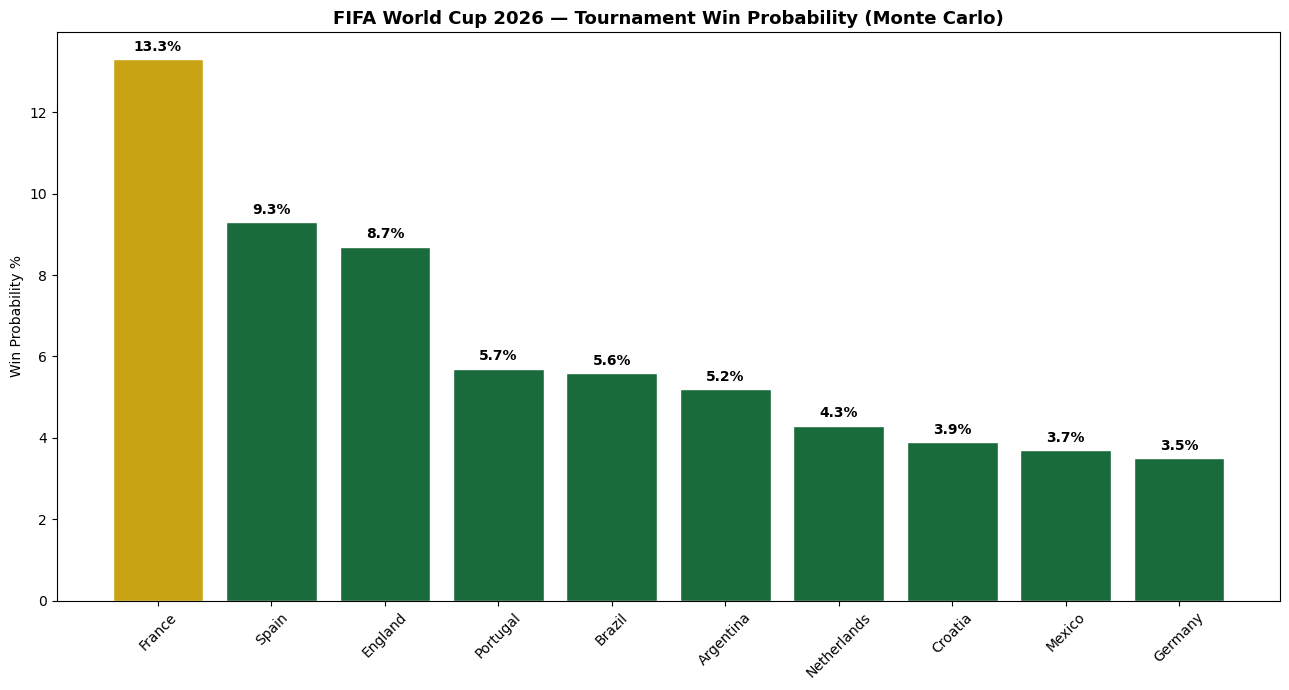


✅ Winner chart saved using Monte Carlo probabilities!


In [9]:
# Chart uses mc_win_probability (from Monte Carlo above)
# NOT the old ranking-based formula

top10 = predictions.nlargest(10, 'mc_win_probability')

print("="*65)
print("🏆 TOP 10 TOURNAMENT WINNERS — MONTE CARLO")
print("="*65)
print(f"\n{'Team':<22}{'Grp':>4}{'Rank':>5}{'Adv%':>6}{'R32%':>6}{'Win%':>6}")
print("-"*65)
for i,(_,row) in enumerate(top10.iterrows(),1):
    medal = "🥇" if i==1 else "🥈" if i==2 else "🥉" if i==3 else f" {i}."
    print(f"{medal} {row['team']:<20}{row['group']:>4}{int(row['fifa_ranking']):>5}"
          f"{row['advancement_prob_pct']:>5}%{row['r32_probability']:>5}%"
          f"{row['mc_win_probability']:>5}%")

fig, ax = plt.subplots(figsize=(13, 7))
colors = ['#c8a415' if i==0 else '#1a6b3c' for i in range(len(top10))]
bars = ax.bar(top10['team'], top10['mc_win_probability'], color=colors, edgecolor='white')
ax.set_title('FIFA World Cup 2026 — Tournament Win Probability (Monte Carlo)', fontsize=13, fontweight='bold')
ax.set_ylabel('Win Probability %')
ax.tick_params(axis='x', rotation=45)
for bar, val in zip(bars, top10['mc_win_probability']):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.2, f'{val}%',
            ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('../data/winner_predictions.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n✅ Winner chart saved using Monte Carlo probabilities!")


## Cell 10 — Save to Azure SQL

In [10]:
from datetime import datetime

def save_predictions(pdf):
    conn = get_connection(); cursor = conn.cursor()
    cursor.execute("DELETE FROM predictions")
    print("🗑️  Cleared old predictions")
    inserted = 0
    for _, row in pdf.iterrows():
        cursor.execute("""
            INSERT INTO predictions (
                team_name, group_name, played, points,
                goal_difference, goals_for, goals_per_game,
                fifa_ranking, momentum_score,
                advancement_prob, advancement_prob_pct,
                win_probability, updated_at
            ) VALUES (?,?,?,?,?,?,?,?,?,?,?,?,?)
        """,
        row['team'], row['group'],
        int(row['played']), int(row['points']),
        int(row['goal_difference']), int(row['goals_for']),
        float(row['goals_per_game']), int(row['fifa_ranking']),
        float(row.get('momentum_score',0)),
        float(row['advancement_prob']),
        float(row['advancement_prob_pct']),
        float(row['mc_win_probability']),   # ← Monte Carlo result
        datetime.now()
        )
        inserted += 1
    conn.commit(); conn.close()
    print(f"✅ Saved {inserted} predictions to Azure SQL")
    print(f"   Updated: {datetime.now().strftime('%d %b %Y %H:%M')}")

save_predictions(predictions)

# Verify
conn  = get_connection()
count = pd.read_sql("SELECT COUNT(*) as cnt FROM predictions", conn).iloc[0]['cnt']
top3  = pd.read_sql("""
    SELECT team_name, advancement_prob_pct, win_probability
    FROM predictions ORDER BY win_probability DESC
""", conn).head(3)
conn.close()

print(f"\n📊 {count} predictions in Azure SQL")
print("\n🏆 Top 3 (Monte Carlo):")
for i,(_,row) in enumerate(top3.iterrows(),1):
    medal = "🥇" if i==1 else "🥈" if i==2 else "🥉"
    print(f"   {medal} {row['team_name']} — Win: {row['win_probability']}% | Adv: {row['advancement_prob_pct']}%")


🗑️  Cleared old predictions
✅ Saved 48 predictions to Azure SQL
   Updated: 28 Jun 2026 15:40

📊 48 predictions in Azure SQL

🏆 Top 3 (Monte Carlo):
   🥇 France — Win: 13.3% | Adv: 98.0%
   🥈 Spain — Win: 9.3% | Adv: 98.0%
   🥉 England — Win: 8.7% | Adv: 98.0%
